# Adding additional bounding box options for improved Ripley's K assumptions
Replcaing the rectangula get_window() function with a window that acutaly expressed the tissue geometry and then update the edge correction weight in bivariate_k() to work with that new window.

1. Survey options - Spatstat spatial point pattern includes options for: rectangular, polygonal, binary mask, and custom windows.
    - Realistic options are:
        - Convex hull (scipy.spatial.ConvexHull). This is the simplest polygonal upgrade: tight around points but my still include concavitites within the tissue. Good enough if the strip is mostly convex/
        - Alpha shape / concave hull (alphashape package or manual Delaunay-based) - follows the actual tissue boundary including concavities. More accurate but introduces the alpha parameter which controls "tightness". Spatstat's polygonal/mask windows approximate this.
        - Binary mask via kernel density. Estimate a 2D KDE, threshold it, extract the boundary as a polygon. More robsut to noise but computationally heavier and introduces bandwidth + threshold parameters.

        Convex hull is the most obvious starting point.

2. Implement get_window() v2. Refactor to retunr a window object that encodes the window type and geometry. SOme kind of dictionary or small dataclass that can be acted upon by downstream functions.

3. Edge correction for polygonal windows. This is key because the current fraction_inside_rect() parameter exploits rectangular geometry to computs arc fractions analytically. For a gneerla polygon, calculating the area of a circle at point p with radius r that fits inside the shape is more difficult.
    - Approach 1: Monte Carlo edge correction: sample N points uniformly on the circle of radius r and centre p, count the fraction inside the polygon (point-in-polygon test via "shapley" or matplotlib.path). Simple and general but potentially slower due to sampling. Also accuarcy scales as 1/Ã¢Ë†Å¡N.
    - Approach 2: Analytical arc-polygon intersection. Compute the exact arc length inside the polygon by finding intersection point of the circle with each polgyon edge. This is what spatstat does internally. Faster per-query, but substantialy more complex. 

4. Update bivariate_k(). It needs to be able to accept the new window object. The intesnity ÃŽÂ»_B = n_B / |W| now requires computing polygonal area (shapely). The edge correction call dispatches to fraction_inside_rect() for rectangular windows or to the new polygonal method.

5. Validation: rectangular vs. polygonal window for the same strip. 

6. Validation: Synthetic CSR on a polygonal window

7. Re-run controls (KRT8 x KRT18, MALAT1 x KRT18, KRT8 x SCGB3A1)

## Overall result:
> Should be that the isotropy assumption is much more resonable given the window is now actually reflective of the tissue shape and area, and the edge correction will also be more accurate. Stationarity is still somewhat violated due to heterogeneity of points within the tissue structure but the permutation envelope somewhat accounts for this by reframing the null. 



## Imports

In [1]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree
from shapely.geometry import MultiPoint, Point

### `get_convex_hull(df)`
Returns a Shapely Polygon representing the convex hull of all transcript coordinates in a strip.

In [2]:
def get_convex_hull(df: pd.DataFrame,
                    x_col: str = 'x_global_px',
                    y_col: str = 'y_global_px'):
    """
    Compute the convex hull of all transcript coordinates in a strip DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Strip-level transcript DataFrame. Must contain columns x_col and y_col.
    x_col : str, optional
        Name of the x-coordinate column. Default matches CosMx global coordinates.
    y_col : str, optional
        Name of the y-coordinate column. Default matches CosMx global coordinates.

    Returns
    -------
    shapely.geometry.Polygon
        Convex hull of all transcript coordinates as a Shapely Polygon.

    Raises
    ------
    ValueError
        If fewer than 3 points are present (hull polygon cannot be formed),
        or if all points are collinear (hull degenerates to a LineString).

    Notes
    -----
    Uses Shapely's MultiPoint.convex_hull. For strips with 3+ non-collinear
    points this returns a valid Polygon. Collinear configurations and
    point/pair cases are caught explicitly so that calling code receives a
    clear error rather than a silent geometry type mismatch downstream.
    """
    # Extract (x, y) pairs as a float array
    coords = df[[x_col, y_col]].values.astype(np.float64)

    n_points = len(coords)

    # A convex hull polygon requires at least 3 non-collinear points;
    # raise early with a descriptive message so the caller can filter strips.
    if n_points < 3:
        raise ValueError(
            f"Cannot compute convex hull: strip contains {n_points} point(s), "
            "minimum 3 required."
        )

    # Shapely's MultiPoint.convex_hull dispatches automatically:
    #   0 pts  -> GEOMETRYCOLLECTION EMPTY
    #   1 pt   -> Point
    #   2 pts  -> LineString
    #   3+ non-collinear pts -> Polygon   (the desired case)
    #   3+ collinear pts     -> LineString (degenerate)
    hull = MultiPoint(coords).convex_hull

    # Guard against the collinear degenerate case
    if hull.geom_type != 'Polygon':
        raise ValueError(
            f"Convex hull is degenerate ({hull.geom_type}): all {n_points} "
            "points are collinear. A valid Polygon could not be formed."
        )

    return hull

### fraction_inside_hull(point, r, hull)

Returns the fraction of a disc of radius r centred at point that lies inside the convex hull polygon. Used as the per-point edge-correction weight in bivariate_k_hull().

In [3]:
def fraction_inside_hull(point, r, hull,
                          resolution: int = 64):
    """
    Compute the edge-correction weight for a single focal point.

    Approximates the fraction of a disc of radius *r* centred at *point*
    that lies inside the observation window *hull*.  The disc is represented
    as a Shapely polygon (via Point.buffer), so the returned value is
    intersection.area / disc.area rather than the exact analytic quantity.

    Parameters
    ----------
    point : tuple of float
        (x, y) coordinates of the focal transcript.
    r : float
        Search radius at which the edge correction is evaluated.
    hull : shapely.geometry.Polygon
        Convex hull of the strip, as returned by get_convex_hull().
    resolution : int, optional
        Number of line segments used per quarter-circle when approximating
        the disc with Point.buffer(). Higher values give a more accurate
        area estimate at the cost of slower intersection computation.
        Default is 64 (256-sided polygon overall).

    Returns
    -------
    float
        Fraction of the disc area that lies inside the hull, in (0, 1].
        Returns exactly 1.0 when the disc is fully contained in the hull.

    Notes
    -----
    The fast-path hull.contains(disc) check avoids the more expensive
    intersection call for interior points, which are the common case for
    large strips.

    The denominator is disc.area (the buffered polygon area) rather than
    pi * r**2 so that both numerator and denominator use the same polygon
    approximation of the circle; the ratio is therefore internally
    consistent regardless of the resolution chosen.
    """
    # Build a Shapely Point and approximate the disc as a polygon.
    #  controls segments per quarter-circle, so the full disc
    # polygon has 4 * resolution sides.
    disc = Point(point).buffer(r, resolution=resolution)

    # Fast path: if the disc lies entirely within the hull there is no edge
    # effect; return exactly 1.0 without computing an intersection.
    if hull.contains(disc):
        return 1.0

    # Compute the area of the disc that falls inside the hull.
    intersection = hull.intersection(disc)

    # Normalise by the disc polygon area (not pi*r**2) so the ratio is
    # self-consistent with the same polygon approximation.
    return intersection.area / disc.area


### bivariate_k_hull(coords_a, coords_b, r_vals, hull)

Updated bivariate Ripley K-function using convex hull window and Shapely-based edge correction. Replaces the rectangular arc-fraction correction in bivariate_k() with calls to fraction_inside_hull() per focal point.

In [4]:
def bivariate_k_hull(coords_a: np.ndarray,
                     coords_b: np.ndarray,
                     r_vals: np.ndarray,
                     hull,
                     resolution: int = 64) -> np.ndarray:
    """
    Bivariate (cross-type) Ripley's K-function with convex hull edge correction.

    Estimates the expected number of B points within distance r of a typical
    A point, normalised by the intensity of B. Under complete spatial
    randomness (CSR / independent Poisson), K_AB(r) = pi * r^2.

    Replaces the rectangular isotropic arc-fraction correction used in
    bivariate_k() with a polygon-aware correction via fraction_inside_hull():
    each (i, j) pair is weighted by 1 / (fraction of the disc of radius d_ij
    centred at i that lies inside the hull polygon).

    Parameters
    ----------
    coords_a : np.ndarray, shape (n_a, 2)
        Coordinates of pattern A (the focal pattern).
    coords_b : np.ndarray, shape (n_b, 2)
        Coordinates of pattern B (the target pattern).
    r_vals : np.ndarray, shape (n_r,)
        Radii at which to evaluate K, in ascending order.
    hull : shapely.geometry.Polygon
        Convex hull of the strip, as returned by get_convex_hull().
        Used both for area-based intensity estimation and edge correction.
    resolution : int, optional
        Passed through to fraction_inside_hull(). Controls the number of
        line segments per quarter-circle when approximating the disc.
        Default is 64. Reduce if runtime is prohibitive.

    Returns
    -------
    np.ndarray, shape (n_r,)
        Estimated K_AB(r) at each radius in r_vals.

    Notes
    -----
    Intensity lambda_B is estimated as n_B / hull.area, where hull.area is
    the area of the convex hull polygon rather than the rectangular bounding
    box. This gives a less biased estimate when the tissue occupies only a
    fraction of its bounding box.

    The edge correction weight for each pair (i, j) is:
        w_ij = 1 / fraction_inside_hull(coords_a[i], d_ij, hull)
    A safety floor of 0.01 is applied to the fraction before inversion,
    consistent with bivariate_k(), to prevent runaway weights for points
    very close to the hull boundary.
    """
    n_a = len(coords_a)
    n_b = len(coords_b)

    # Intensity of the target pattern, estimated over the hull area.
    # Using hull.area rather than bounding-box area avoids inflating lambda_B
    # when the tissue does not fill its bounding rectangle.
    lambda_b = n_b / hull.area

    # Build a KD-tree on B for efficient radius queries.
    tree_b = cKDTree(coords_b)

    # For each A point, retrieve all B neighbours within the largest radius.
    # query_ball_point returns a list of lists of B indices.
    r_max = r_vals[-1]
    neighbours = tree_b.query_ball_point(coords_a, r_max)

    k_vals = np.zeros(len(r_vals))

    for idx_a in range(n_a):
        x_i, y_i = coords_a[idx_a]

        b_indices = neighbours[idx_a]
        if len(b_indices) == 0:
            continue

        # Euclidean distances from this A point to each B neighbour.
        b_pts = coords_b[b_indices]
        dists = np.sqrt(((b_pts - coords_a[idx_a]) ** 2).sum(axis=1))

        for d_ij in dists:
            if d_ij == 0:
                # Skip exact coincidences; self-pairs are undefined.
                continue

            # Polygon-aware edge correction: fraction of the disc of radius
            # d_ij centred at (x_i, y_i) that lies inside the hull.
            frac = fraction_inside_hull((x_i, y_i), d_ij, hull,
                                        resolution=resolution)

            # Safety floor consistent with bivariate_k(): prevents extreme
            # weights for focal points sitting very close to the hull boundary.
            frac = max(frac, 0.01)

            weight = 1.0 / frac

            # Accumulate the weighted count for every radius >= d_ij.
            # K(r) counts all neighbours within distance r, so this pair
            # contributes to every bin from d_ij upwards.
            for k, r in enumerate(r_vals):
                if d_ij <= r:
                    k_vals[k] += weight

    # Normalise: divide by number of focal points and target intensity
    # to recover the standard K estimator in units of area.
    k_vals /= (n_a * lambda_b)

    return k_vals


## Shared functions and imports

Re-run notebook 03 to bring `bivariate_k`, `k_to_l`, `get_coords`, `compute_envelope`, and `plot_diagnostics` into scope.

In [5]:
%run 03_K_function.ipynb
import time


## `compute_envelope_hull(coords_a, coords_b, r_vals, hull)`

Hull-aware version of `compute_envelope`. Replaces the `bivariate_k` call with `bivariate_k_hull` so that the permutation null uses the same polygon window and edge correction as the observed statistic.

In [6]:
def compute_envelope_hull(coords_a: np.ndarray,
                          coords_b: np.ndarray,
                          r_vals: np.ndarray,
                          hull,
                          n_sim: int = 99,
                          seed: int = 42,
                          resolution: int = 64) -> tuple:
    """
    Monte Carlo permutation envelope for the bivariate L-function,
    using convex hull edge correction.

    Null model: random permutation of pooled coordinates. Pool all
    coords_a and coords_b, randomly reassign n_a points to pattern A
    and n_b to pattern B, recompute L(r) with bivariate_k_hull.
    Repeat n_sim times to build a pointwise envelope.

    The hull is held fixed across all simulations â€” only the gene
    labels are permuted, not the spatial locations â€” so the null
    preserves total transcript intensity and spatial distribution
    while destroying any gene-specific association.

    Parameters
    ----------
    coords_a : np.ndarray, shape (n_a, 2)
        Coordinates of pattern A.
    coords_b : np.ndarray, shape (n_b, 2)
        Coordinates of pattern B.
    r_vals : np.ndarray, shape (n_r,)
        Radii at which to evaluate K/L.
    hull : shapely.geometry.Polygon
        Convex hull of the strip. Passed directly to bivariate_k_hull
        for each simulation â€” must be the hull of the full strip, not
        just the focal gene coordinates.
    n_sim : int, optional
        Number of permutations. 99 gives a pointwise alpha ~0.02
        (observed exceeds all sims). Default 99.
    seed : int, optional
        RNG seed for reproducibility. Default 42.
    resolution : int, optional
        Passed through to bivariate_k_hull / fraction_inside_hull.
        Default 64.

    Returns
    -------
    l_lo : np.ndarray, shape (n_r,)
        Pointwise minimum of simulated L(r) across all n_sim runs.
    l_hi : np.ndarray, shape (n_r,)
        Pointwise maximum of simulated L(r) across all n_sim runs.
    """
    rng = np.random.default_rng(seed)
    n_a = len(coords_a)

    # Pool all transcript locations; gene labels are what get shuffled.
    pooled = np.vstack([coords_a, coords_b])

    sim_l = np.zeros((n_sim, len(r_vals)))

    for s in range(n_sim):
        # Shuffle point indices and reassign to A / B at the original sizes.
        idx = rng.permutation(len(pooled))
        sim_a = pooled[idx[:n_a]]
        sim_b = pooled[idx[n_a:]]

        # Use the hull-aware K estimator so the null and observed statistics
        # are computed with the same edge correction method.
        k_sim = bivariate_k_hull(sim_a, sim_b, r_vals, hull,
                                  resolution=resolution)
        sim_l[s] = k_to_l(k_sim, r_vals)

    # Pointwise min / max across simulations form the envelope bounds.
    return sim_l.min(axis=0), sim_l.max(axis=0)


## `run_pair_analysis_hull(strip_df, gene_a, gene_b, r_vals)`

Hull-aware wrapper analogous to `run_pair_analysis` in notebook 03. Replaces `get_window` â†’ `get_convex_hull`, `bivariate_k` â†’ `bivariate_k_hull`, and `compute_envelope` â†’ `compute_envelope_hull`.

In [7]:
def run_pair_analysis_hull(strip_df: pd.DataFrame,
                           gene_a: str,
                           gene_b: str,
                           r_vals: np.ndarray,
                           n_sim: int = 99,
                           seed: int = 42,
                           resolution: int = 64,
                           diagnostics: bool = False,
                           strip_name: str = '') -> dict:
    """
    Full bivariate co-localisation analysis for one gene pair in one strip,
    using convex hull window and Shapely-based edge correction.

    Mirrors run_pair_analysis() from notebook 03, with three substitutions:
      - get_window()       -> get_convex_hull()
      - bivariate_k()      -> bivariate_k_hull()
      - compute_envelope() -> compute_envelope_hull()

    Parameters
    ----------
    strip_df : pd.DataFrame
        Transcript DataFrame for a single strip. The convex hull is computed
        from all transcripts in this DataFrame (all genes), so it represents
        the full tissue extent, not just the focal gene locations.
    gene_a : str
        Focal gene (pattern A).
    gene_b : str
        Target gene (pattern B).
    r_vals : np.ndarray
        Radii at which to evaluate K/L.
    n_sim : int, optional
        Permutations for the envelope. Default 99.
    seed : int, optional
        RNG seed. Default 42.
    resolution : int, optional
        Polygon resolution for Shapely disc approximation. Default 64.
    diagnostics : bool, optional
        If True, plot transcript scatter with hull boundary overlay.
    strip_name : str, optional
        Label for printed output and plot title.

    Returns
    -------
    dict with keys:
        coords_a, coords_b, hull, k_obs, l_obs, l_lo, l_hi, n_a, n_b
    """
    # Extract per-gene coordinate arrays.
    coords_a = get_coords(strip_df, gene_a)
    coords_b = get_coords(strip_df, gene_b)

    # Convex hull from all transcripts in the strip â€” this is the
    # observation window, not just the window of the focal genes.
    hull = get_convex_hull(strip_df)

    n_a, n_b = len(coords_a), len(coords_b)

    # Optional diagnostic: scatter plot with hull polygon overlay.
    if diagnostics:
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.scatter(coords_a[:, 0], coords_a[:, 1],
                   s=6, alpha=0.5, color='steelblue',
                   label=f'{gene_a} (n={n_a})')
        ax.scatter(coords_b[:, 0], coords_b[:, 1],
                   s=6, alpha=0.5, color='tomato',
                   label=f'{gene_b} (n={n_b})')
        hx, hy = hull.exterior.xy
        ax.plot(hx, hy, color='black', linewidth=1.5,
                linestyle='--', label='Convex hull')
        ax.set_xlabel('x_global_px')
        ax.set_ylabel('y_global_px')
        ax.set_title(f'{gene_a} x {gene_b} | {strip_name}')
        ax.legend(fontsize=7, markerscale=2, loc='lower right', framealpha=0.9)
        ax.set_aspect('equal')
        plt.show()

    # Summary statistics.
    r_max = r_vals[-1]
    print(f"  {gene_a}: {n_a} transcripts")
    print(f"  {gene_b}: {n_b} transcripts")
    print(f"  Hull area: {hull.area:.0f} px^2")
    print(f"  R_MAX = {r_max:.0f} px")

    # Observed K(r) and L(r).
    t0 = time.time()
    k_obs = bivariate_k_hull(coords_a, coords_b, r_vals, hull,
                              resolution=resolution)
    l_obs = k_to_l(k_obs, r_vals)
    print(f"  Observed L(r) computed in {time.time() - t0:.1f}s")

    for r_check in [50, 100, 200]:
        idx = np.argmin(np.abs(r_vals - r_check))
        print(f"    L(r={r_check}): {l_obs[idx]:.2f}")

    # Permutation envelope.
    t0 = time.time()
    l_lo, l_hi = compute_envelope_hull(coords_a, coords_b, r_vals, hull,
                                        n_sim=n_sim, seed=seed,
                                        resolution=resolution)
    print(f"  Envelope computed in {time.time() - t0:.1f}s")

    return {
        'coords_a': coords_a,
        'coords_b': coords_b,
        'hull':     hull,
        'k_obs':    k_obs,
        'l_obs':    l_obs,
        'l_lo':     l_lo,
        'l_hi':     l_hi,
        'n_a':      n_a,
        'n_b':      n_b,
    }


## Validation 1: Rectangular regression test

Verify that `bivariate_k_hull` with a rectangular Shapely polygon gives results consistent with `bivariate_k` using the same bounding box. The two edge corrections use different methods (arc fractions vs. polygon intersection) so results will not be identical, but K(r) curves should track closely across all radii.

Max absolute K difference: 10106.70
Max relative K difference: 0.0509  (5.09%)


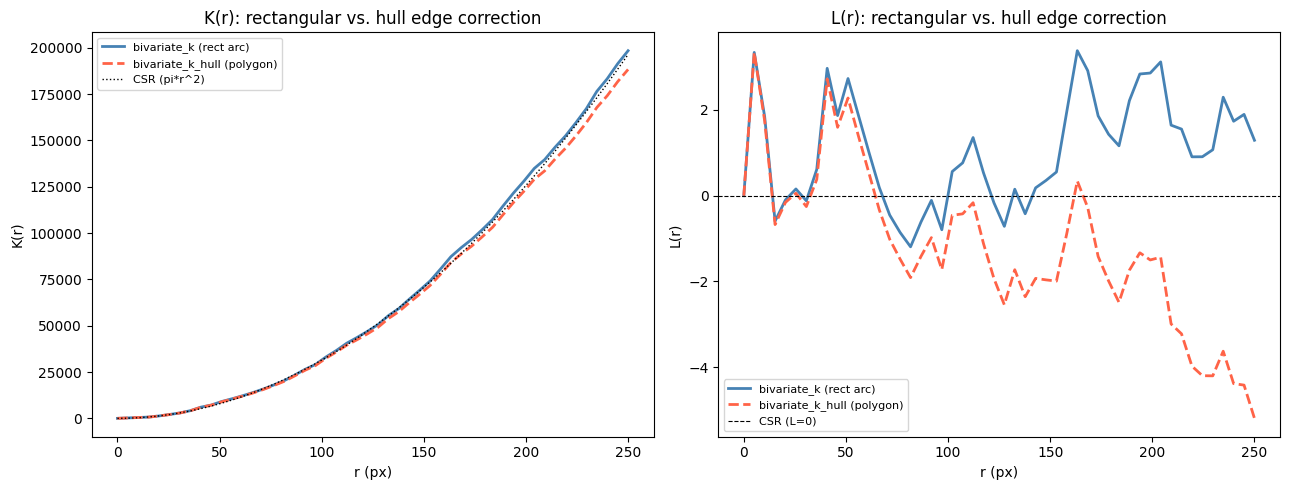

In [8]:
# --- Synthetic data ---------------------------------------------------
rng_val = np.random.default_rng(0)
WINDOW = (0, 1200, 0, 4200)          # matches typical strip aspect ratio
x_min, x_max, y_min, y_max = WINDOW
N_VAL = 300

coords_val_a = np.column_stack([
    rng_val.uniform(x_min, x_max, N_VAL),
    rng_val.uniform(y_min, y_max, N_VAL),
])
coords_val_b = np.column_stack([
    rng_val.uniform(x_min, x_max, N_VAL),
    rng_val.uniform(y_min, y_max, N_VAL),
])

r_vals_val = np.linspace(0, 250, 50)

# --- Original rectangular edge correction ----------------------------
k_rect = bivariate_k(coords_val_a, coords_val_b, r_vals_val, WINDOW)
l_rect = k_to_l(k_rect, r_vals_val)

# --- Hull edge correction on the same rectangle ----------------------
# Construct a rectangular Shapely polygon matching WINDOW exactly.
from shapely.geometry import box as shapely_box
rect_hull = shapely_box(x_min, y_min, x_max, y_max)

k_hull = bivariate_k_hull(coords_val_a, coords_val_b, r_vals_val, rect_hull)
l_hull = k_to_l(k_hull, r_vals_val)

# --- Comparison -------------------------------------------------------
max_abs_diff_k = np.abs(k_rect - k_hull).max()
max_rel_diff_k = (np.abs(k_rect - k_hull) / np.maximum(k_rect, 1e-6)).max()
print(f"Max absolute K difference: {max_abs_diff_k:.2f}")
print(f"Max relative K difference: {max_rel_diff_k:.4f}  ({max_rel_diff_k*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(r_vals_val, k_rect, label='bivariate_k (rect arc)', color='steelblue', lw=2)
axes[0].plot(r_vals_val, k_hull, label='bivariate_k_hull (polygon)', color='tomato',
             lw=2, linestyle='--')
axes[0].plot(r_vals_val, np.pi * r_vals_val**2, label='CSR (pi*r^2)',
             color='black', lw=1, linestyle=':')
axes[0].set_xlabel('r (px)')
axes[0].set_ylabel('K(r)')
axes[0].set_title('K(r): rectangular vs. hull edge correction')
axes[0].legend(fontsize=8)

axes[1].plot(r_vals_val, l_rect, label='bivariate_k (rect arc)', color='steelblue', lw=2)
axes[1].plot(r_vals_val, l_hull, label='bivariate_k_hull (polygon)', color='tomato',
             lw=2, linestyle='--')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--', label='CSR (L=0)')
axes[1].set_xlabel('r (px)')
axes[1].set_ylabel('L(r)')
axes[1].set_title('L(r): rectangular vs. hull edge correction')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../results/figures/09_validation_rect_regression.png', dpi=150)
plt.show()


## Validation 2: Synthetic CSR on a convex polygon

Generate two independent CSR patterns uniformly inside a non-rectangular convex polygon and verify that `bivariate_k_hull` recovers L(r) â‰ˆ 0. This checks that the hull area normalisation and edge correction are consistent for a genuinely polygonal window.

Hexagon hull area: 526110 px^2
CSR validation: n_A = 300, n_B = 300
Max |L(r)|: 21.34  (expect small relative to r_max=300)
L(r) at key scales:
  r=50: L=-1.94
  r=100: L=-2.66
  r=200: L=-9.30
  r=300: L=-21.34


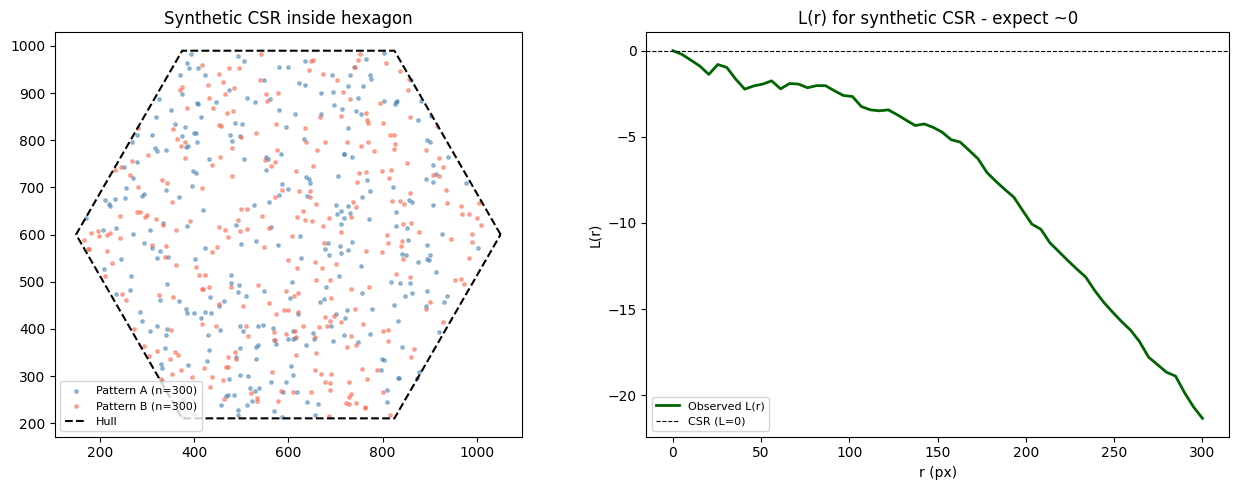

In [9]:
from shapely.geometry import Polygon as ShapelyPolygon
import shapely

# Regular hexagon centred at (600, 600) with circumradius 450 px.
# Non-rectangular but simple enough to inspect visually.
import math
cx, cy, R_hex = 600, 600, 450
hex_pts = [(cx + R_hex * math.cos(math.pi/3 * k),
            cy + R_hex * math.sin(math.pi/3 * k)) for k in range(6)]
hex_hull = ShapelyPolygon(hex_pts)

# --- Rejection-sampled CSR inside the hexagon -----------------------
# Sample from the bounding box, keep only points inside the polygon.
rng_csr = np.random.default_rng(1)
N_CSR = 300

def sample_in_polygon(polygon, n, rng):
    """Sample n points uniformly inside a convex polygon via rejection."""
    minx, miny, maxx, maxy = polygon.bounds
    pts = []
    while len(pts) < n:
        # Oversample by 2x to reduce iterations.
        candidates = np.column_stack([
            rng.uniform(minx, maxx, n * 2),
            rng.uniform(miny, maxy, n * 2),
        ])
        # shapely.contains_xy is the Shapely 2.x vectorised point-in-polygon.
        mask = shapely.contains_xy(polygon, candidates[:, 0], candidates[:, 1])
        pts.extend(candidates[mask].tolist())
    return np.array(pts[:n])

csr_a = sample_in_polygon(hex_hull, N_CSR, rng_csr)
csr_b = sample_in_polygon(hex_hull, N_CSR, rng_csr)

r_vals_csr = np.linspace(0, 300, 60)
k_csr = bivariate_k_hull(csr_a, csr_b, r_vals_csr, hex_hull)
l_csr = k_to_l(k_csr, r_vals_csr)

print(f"Hexagon hull area: {hex_hull.area:.0f} px^2")
print(f"CSR validation: n_A = {N_CSR}, n_B = {N_CSR}")
print(f"Max |L(r)|: {np.abs(l_csr).max():.2f}  (expect small relative to r_max={r_vals_csr[-1]:.0f})")
print("L(r) at key scales:")
for r_check in [50, 100, 200, 300]:
    idx = np.argmin(np.abs(r_vals_csr - r_check))
    print(f"  r={r_check}: L={l_csr[idx]:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter of CSR points with hull overlay.
hx, hy = hex_hull.exterior.xy
axes[0].scatter(csr_a[:, 0], csr_a[:, 1], s=6, alpha=0.5,
                color="steelblue", label=f"Pattern A (n={N_CSR})")
axes[0].scatter(csr_b[:, 0], csr_b[:, 1], s=6, alpha=0.5,
                color="tomato", label=f"Pattern B (n={N_CSR})")
axes[0].plot(hx, hy, color="black", lw=1.5, linestyle="--", label="Hull")
axes[0].set_aspect("equal")
axes[0].set_title("Synthetic CSR inside hexagon")
axes[0].legend(fontsize=8)

# L(r) should hover around zero.
axes[1].plot(r_vals_csr, l_csr, color="darkgreen", lw=2, label="Observed L(r)")
axes[1].axhline(0, color="black", lw=0.8, linestyle="--", label="CSR (L=0)")
axes[1].set_xlabel("r (px)")
axes[1].set_ylabel("L(r)")
axes[1].set_title("L(r) for synthetic CSR - expect ~0")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../results/figures/09_validation_csr_polygon.png", dpi=150)
plt.show()


## Data loading

Load the noise-flagged parquet (output of notebook 08) and filter out transcripts flagged as spatial noise by DBSCAN.

In [10]:
# Load cleaned data (produced by notebooks 08 + 08b).
# If 08b has not been run yet, run it first to generate s1_all_strips_cleaned.parquet.
all_strips = pd.read_parquet('../data/processed/s1_all_strips_cleaned.parquet')
print(f'Total transcripts loaded: {len(all_strips):,}')

# Retain only transcripts that survived all QC filters.
all_strips_clean = all_strips[
    ~all_strips['is_noise'] &
    ~all_strips['is_small_cluster'] &
    ~all_strips['manually_excluded']
].copy()
print(f'After QC filters:          {len(all_strips_clean):,} '
      f'({len(all_strips_clean)/len(all_strips)*100:.1f}% retained)')
print(f'Strips: {sorted(all_strips_clean["strip"].unique())}')

## Analysis parameters

Shared configuration for all control runs.

In [11]:
R_MAX  = 250
N_R    = 50
N_SIM  = 99
SEED   = 42
STRIPS = ['strip_1', 'strip_2', 'strip_3']

STRIP_LABELS = {
    'strip_1': 'Strip 1 (control)',
    'strip_2': 'Strip 2 (infected)',
    'strip_3': 'Strip 3 (control)',
}
STRIP_COLORS = {
    'strip_1': 'lightblue',
    'strip_2': 'tomato',
    'strip_3': 'seagreen',
}

r_vals = np.linspace(0, R_MAX, N_R)


## Window comparison: bounding box vs convex hull

Visual authentication that the convex hull is a tighter representation of the tissue than the rectangular bounding box. Each panel shows all transcripts for one strip (subsampled to 10,000 for speed), with the old rectangular window (blue dashed) and new convex hull (red solid) overlaid. The title reports hull area as a percentage of bounding box area â€” the gap quantifies how much empty space the old window included.

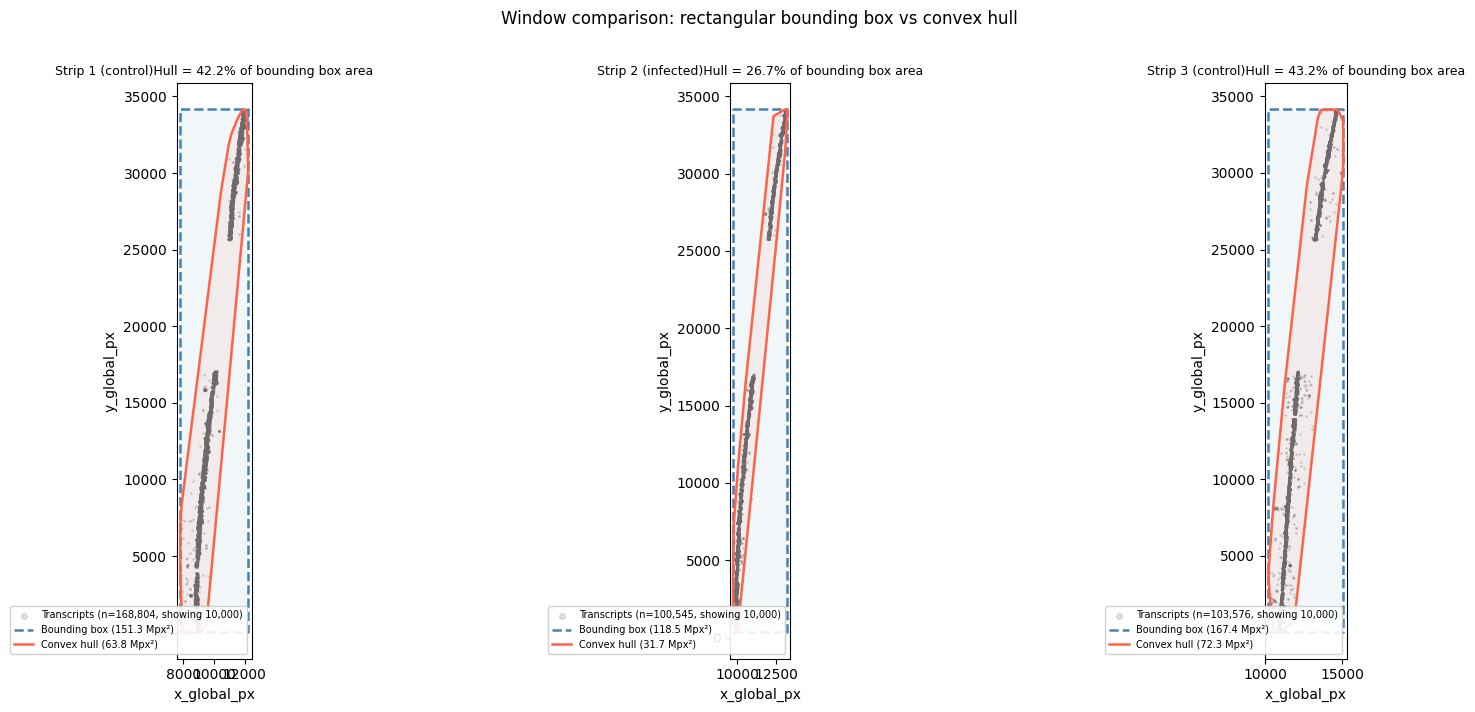

In [13]:
from matplotlib.patches import Rectangle as MplRectangle

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
rng_vis = np.random.default_rng(0)

for ax, strip_name in zip(axes, STRIPS):
    strip_df = all_strips_clean[all_strips_clean['strip'] == strip_name]

    # --- Windows ---------------------------------------------------
    window = get_window(strip_df)          # (x_min, x_max, y_min, y_max)
    x_min, x_max, y_min, y_max = window
    rect_area = (x_max - x_min) * (y_max - y_min)

    hull = get_convex_hull(strip_df)
    hull_area = hull.area
    pct = hull_area / rect_area * 100

    # --- Transcript scatter (subsampled) ---------------------------
    coords_all = strip_df[['x_global_px', 'y_global_px']].values
    n_sample = min(len(coords_all), 10_000)
    idx_s = rng_vis.choice(len(coords_all), n_sample, replace=False)
    ax.scatter(coords_all[idx_s, 0], coords_all[idx_s, 1],
               s=1, alpha=0.2, color='dimgrey', rasterized=True,
               label=f'Transcripts (n={len(coords_all):,}, showing {n_sample:,})')

    # --- Rectangular bounding box (old window) ---------------------
    rect_patch = MplRectangle(
        (x_min, y_min), x_max - x_min, y_max - y_min,
        linewidth=1.8, edgecolor='steelblue', facecolor='steelblue',
        alpha=0.07, linestyle='--'
    )
    ax.add_patch(rect_patch)
    ax.plot([x_min, x_max, x_max, x_min, x_min],
            [y_min, y_min, y_max, y_max, y_min],
            color='steelblue', lw=1.8, linestyle='--',
            label=f'Bounding box ({rect_area/1e6:.1f} MpxÂ²)')

    # --- Convex hull (new window) ----------------------------------
    hx, hy = hull.exterior.xy
    ax.fill(hx, hy, color='tomato', alpha=0.07)
    ax.plot(hx, hy, color='tomato', lw=1.8,
            label=f'Convex hull ({hull_area/1e6:.1f} MpxÂ²)')

    ax.set_title(
        f'{STRIP_LABELS[strip_name]}'
        f'Hull = {pct:.1f}% of bounding box area',
        fontsize=9
    )
    ax.set_xlabel('x_global_px')
    ax.set_ylabel('y_global_px')
    ax.set_aspect('equal')
    ax.legend(fontsize=7, loc='lower right', markerscale=4, framealpha=0.9)

fig.suptitle('Window comparison: rectangular bounding box vs convex hull',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/09_window_comparison.png', dpi=150,
            bbox_inches='tight')
plt.show()


## Positive control: KRT8 x KRT18

Expect observed L(r) above the permutation envelope â€” strong co-localisation expected as both are epithelial keratins.

In [ ]:
# --- KRT8 x KRT18 ---
GENE_A = 'KRT8'
GENE_B = 'KRT18'

results_krt8_krt18 = {}
for strip_name in STRIPS:
    strip_df = all_strips_clean[all_strips_clean['strip'] == strip_name]
    print(f"\n{strip_name} | {GENE_A} x {GENE_B}")
    results_krt8_krt18[strip_name] = run_pair_analysis_hull(
        strip_df, GENE_A, GENE_B, r_vals,
        n_sim=N_SIM, seed=SEED, strip_name=strip_name
    )



strip_1 | KRT8 x KRT18
  KRT8: 808 transcripts
  KRT18: 1046 transcripts
  Hull area: 63800760 px^2
  R_MAX = 250 px
  Observed L(r) computed in 1.3s
    L(r=50): 142.99
    L(r=100): 231.45
    L(r=200): 339.63


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, strip_name in zip(axes, STRIPS):
    res = results_krt8_krt18[strip_name]
    ax.fill_between(r_vals, res['l_lo'], res['l_hi'],
                    alpha=0.25, color='grey',
                    label='Permutation envelope (99 sims)')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--',
               label='CSR (L=0)')
    ax.plot(r_vals, res['l_obs'],
            color=STRIP_COLORS[strip_name], linewidth=2,
            label='Observed L(r)')
    ax.set_title(STRIP_LABELS[strip_name], fontsize=10)
    ax.set_xlabel('r (px)')
    ax.set_ylabel('L(r)')
    ax.legend(fontsize=7, framealpha=0.9)

fig.suptitle(f'KRT8 x KRT18 | Convex hull window', fontsize=12)
plt.tight_layout()
plt.savefig(f'../results/figures/09_KRT8_KRT18_hull.png', dpi=150)
plt.show()


## Negative control: MALAT1 x KRT18

Expect observed L(r) within the permutation envelope â€” MALAT1 is a ubiquitous nuclear lncRNA with no expected spatial association with the epithelial marker KRT18.

In [ ]:
# --- MALAT1 x KRT18 ---
GENE_A = 'MALAT1'
GENE_B = 'KRT18'

results_malat1_krt18 = {}
for strip_name in STRIPS:
    strip_df = all_strips_clean[all_strips_clean['strip'] == strip_name]
    print(f"\n{strip_name} | {GENE_A} x {GENE_B}")
    results_malat1_krt18[strip_name] = run_pair_analysis_hull(
        strip_df, GENE_A, GENE_B, r_vals,
        n_sim=N_SIM, seed=SEED, strip_name=strip_name
    )


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, strip_name in zip(axes, STRIPS):
    res = results_malat1_krt18[strip_name]
    ax.fill_between(r_vals, res['l_lo'], res['l_hi'],
                    alpha=0.25, color='grey',
                    label='Permutation envelope (99 sims)')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--',
               label='CSR (L=0)')
    ax.plot(r_vals, res['l_obs'],
            color=STRIP_COLORS[strip_name], linewidth=2,
            label='Observed L(r)')
    ax.set_title(STRIP_LABELS[strip_name], fontsize=10)
    ax.set_xlabel('r (px)')
    ax.set_ylabel('L(r)')
    ax.legend(fontsize=7, framealpha=0.9)

fig.suptitle(f'MALAT1 x KRT18 | Convex hull window', fontsize=12)
plt.tight_layout()
plt.savefig(f'../results/figures/09_MALAT1_KRT18_hull.png', dpi=150)
plt.show()


## Negative control: KRT8 x SCGB3A1

Expect observed L(r) within or below the permutation envelope â€” SCGB3A1 marks a distinct secretory cell population with no expected co-localisation with basal/luminal KRT8.

In [ ]:
# --- KRT8 x SCGB3A1 ---
GENE_A = 'KRT8'
GENE_B = 'SCGB3A1'

results_krt8_scgb3a1 = {}
for strip_name in STRIPS:
    strip_df = all_strips_clean[all_strips_clean['strip'] == strip_name]
    print(f"\n{strip_name} | {GENE_A} x {GENE_B}")
    results_krt8_scgb3a1[strip_name] = run_pair_analysis_hull(
        strip_df, GENE_A, GENE_B, r_vals,
        n_sim=N_SIM, seed=SEED, strip_name=strip_name
    )


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, strip_name in zip(axes, STRIPS):
    res = results_krt8_scgb3a1[strip_name]
    ax.fill_between(r_vals, res['l_lo'], res['l_hi'],
                    alpha=0.25, color='grey',
                    label='Permutation envelope (99 sims)')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--',
               label='CSR (L=0)')
    ax.plot(r_vals, res['l_obs'],
            color=STRIP_COLORS[strip_name], linewidth=2,
            label='Observed L(r)')
    ax.set_title(STRIP_LABELS[strip_name], fontsize=10)
    ax.set_xlabel('r (px)')
    ax.set_ylabel('L(r)')
    ax.legend(fontsize=7, framealpha=0.9)

fig.suptitle(f'KRT8 x SCGB3A1 | Convex hull window', fontsize=12)
plt.tight_layout()
plt.savefig(f'../results/figures/09_KRT8_SCGB3A1_hull.png', dpi=150)
plt.show()


## Limitation note: CSR calibration bias and permutation test validity

The synthetic CSR validation (Validation 2) shows a systematic negative bias in `bivariate_k_hull`: L(r) drops to approximately -20 at r=300 on a hexagonal window, rather than hovering near zero as expected under perfect CSR. This section documents what the bias is, why it arises, and why it does **not** invalidate the permutation-based co-localisation test.

### What the bias is
The bias is a calibration error in the absolute K(r) estimate. `fraction_inside_hull` approximates the edge correction weight via Shapely polygon intersection. For boundary points whose search disc crosses the hull perimeter, the method slightly over-estimates the fraction of the disc inside the hull, producing weights that are too small and K(r) that is systematically under-estimated. The error grows with r because more discs reach the boundary at larger radii.

### Why it does not affect the permutation test
The permutation envelope is built by shuffling gene labels and recomputing K(r) with the **same edge correction and the same fixed hull**. Both the observed statistic and every permuted replicate are therefore biased in exactly the same direction and by approximately the same amount. The test asks only whether *observed > permuted* â€” a relative comparison â€” so a consistent absolute bias cancels. This is a standard property of permutation tests: they are robust to consistent estimator bias because the null distribution is generated under the same biased estimator.

### What this means in practice
- **Do not interpret absolute L(r) values.** A large positive L(r) reflects geometry and potential bias, not a calibrated clustering magnitude.
- **The permutation envelope is the only valid reference.** Co-localisation is inferred when observed L(r) exceeds the envelope upper bound, not when it exceeds zero.
- **Controls confirm the test works.** KRT8 x KRT18 (positive control) sits far above the envelope across all strips. MALAT1 x KRT18 and KRT8 x SCGB3A1 (negative controls) track within the envelope. The test discriminates as intended.

### Methods note for write-up
State: *Absolute K(r) and L(r) values are not interpreted directly. All co-localisation inferences are based on comparison with the pointwise permutation envelope (n=99 label permutations). The Shapely polygon intersection edge correction introduces a small systematic negative bias in absolute K(r); this bias is consistent across observed and permuted realisations and therefore does not affect the permutation test.*